In [1]:
%load_ext autoreload
%autoreload 2

# Data length: long vs short doc (40B)

Memorization comparison: isolates the effect of training-document length -- long Gutenberg documents kept whole, the filler data consists of long documents (raw mean 7567 tokens, packed mean 3934) vs the same documents split into 1024-token segments (raw mean 992, packed mean 885). Reads mem-results/SparseGutenberg.

In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../../PDM')
sys.path.append(f'{PDM_DIR}/src')

import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../../..')
import matplotlib.pyplot as plt

from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_mem_results_scores_grid, load_long_inference_nll_grid
from attn_bench.plotting.heatmap import plot_models_heatmap, plot_models_heatmap_panel
from attn_bench.plotting.utils import SEQ_LEN
from attn_bench.plotting.long_inference import plot_loss_panel

## Load memorization results

In [11]:
MEM_MODELS = ['full-scf8', 'full-long-docs-scf8', 'full-short-docs-scf8']

OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000]
PREFIXES = [50, 100, 250, 500, 750, 1000, 2000, 3000]
SUFFIXES = [50, 500]

results_grid = load_mem_results_scores_grid(
    OFFSETS, PREFIXES, SUFFIXES, models=MEM_MODELS, results_base=model_registry.MEM_RESULTS_DIR
)

## Rouge-L
full-long-docs-scf8/full-short-docs-scf8 only have one captured point (offset=0, prefix=500, suffix=500) -- a single heatmap, not a swept panel.

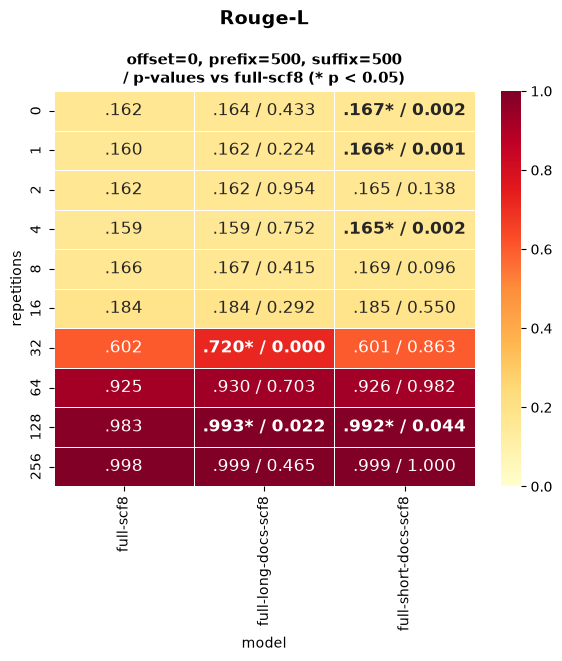

In [12]:
entry = results_grid[(0, 500, 500)]  # key = (offset, prefix, suffix)
plot_models_heatmap(entry, 'Rouge-L', offset=0, prefix=500, suffix=500, models=MEM_MODELS, reference='full-scf8')

## Behavioral: long vs split-1024 (old mismatched scf8-scf1)
Same eval task (long Gutenberg excerpts) for both training variants, so any difference in
position-wise loss traces the training-document-structure effect, not the eval.
Per-sequence breakdown lives in `long_inference_individual.ipynb`.

In [13]:
BEHAV_MODELS = ['full-long-docs-scf8-scf1', 'full-short-docs-scf8-scf1']
BEHAV_REPS = [0, 8, 32, 256]

nll_grid = load_long_inference_nll_grid(BEHAV_REPS, models=BEHAV_MODELS)

BEHAV_VLINES = {
    "seq length": SEQ_LEN,
    "mean long chunk length": 3934,
    "mean long-split1024 chunk length": 885,
    "median long chunk length": 3800,
    "median long-split1024 chunk length": 1024,
}

def _behav_subset(grid, reps):
    return {lab: {r: d[r] for r in reps if r in d} for lab, d in grid.items()}

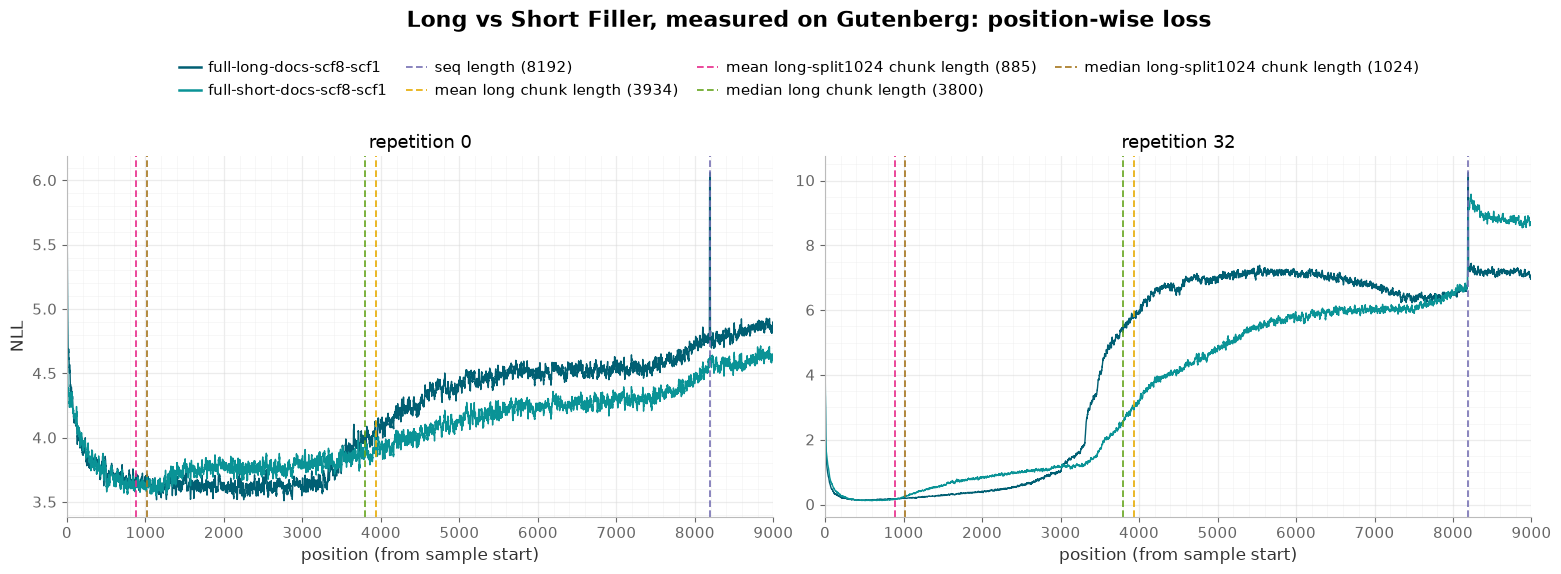

In [14]:
fig = plot_loss_panel(_behav_subset(nll_grid, [0, 32]), ncols=2, metric="nll", show_random_baseline=False,
                      smooth_window=10, xmin=0, xmax=9000, show_std=False, show_count=False, sharey=False,
                      suptitle="Long vs Short Filler, measured on Gutenberg: position-wise loss",
                      colors=model_registry.MODEL_COLORS, vlines=BEHAV_VLINES)
plt.show()

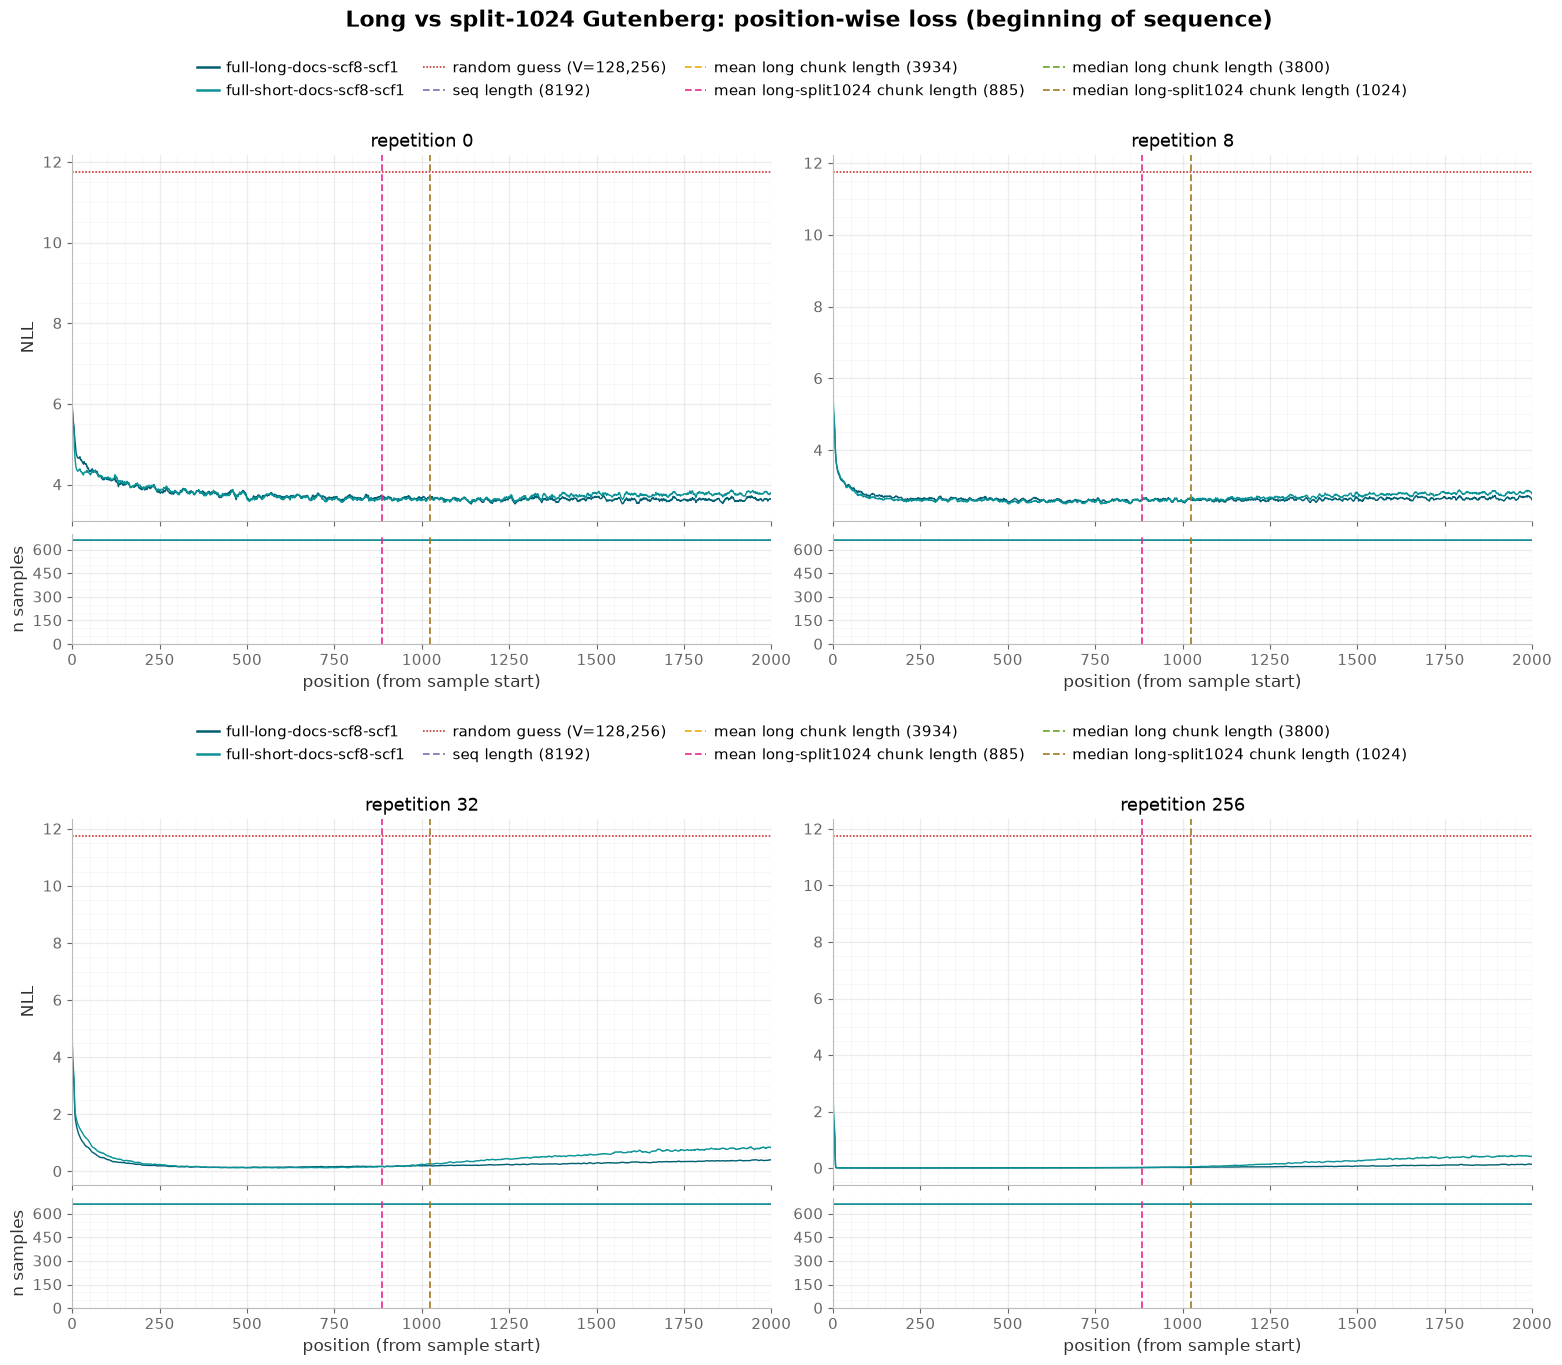

In [15]:
# Zoomed into the very start of the sequence -- edit xmin/xmax to look at any other window.
fig = plot_loss_panel(nll_grid, ncols=2, metric="nll", show_random_baseline=True,
                      smooth_window=10, xmin=0, xmax=2000, show_std=False, show_count=True, sharey=False,
                      suptitle="Long vs split-1024 Gutenberg: position-wise loss (beginning of sequence)",
                      colors=model_registry.MODEL_COLORS, vlines=BEHAV_VLINES)
plt.show()